In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

In [2]:
target_d_L = 75.4#Mpc

In [3]:
base = "IPTA_MDC2_G2D2_detection_"
crnr_plt_title1 =base+'corner plot_simulated'
crnr_plt_title2 =base
trace_plot_title = base+'trace_plot'
BF_histogram_title = base+'log10A_histogram'
BFerr_title = base+'log10A_histogram_error'

In [4]:
pwd

'/scratch/na00078/projects/IPTA_MDC2/post_processing'

## Generate Outfile

## Run Outfile

In [5]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_simulated_outfile.h5"
infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]
    
    
# --- this function must be defined at top-level (not indented under 'with') ---
def find_keys(g, key="tref"):
    if isinstance(g, h5py.Group):
        for k, v in g.items():
            if key in k.lower():
                print(k, "=", v[()])
            if isinstance(v, h5py.Group):
                find_keys(v, key)

with h5py.File(infile, 'r') as f:
    find_keys(f, key="tref")

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_simulated_outfile.h5
8
(100000000, 8)
(1, 100000000)


## Corner Plots

In [6]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {
    "0_cos_gwtheta": np.cos(0.6387905062299246),
    "0_cos_inc": 0.8412486994612669,
    "0_gwphi": 3.3335788713091694,
    "0_log10_fgw": np.log10(3.7e-9),
    "0_log10_h": -13.668773493298787,
    "0_log10_mc": np.log10(4.3e9),
    "phase0": 0.24434609527920614,
    "psi": 1.1187560505283651,
    "distance": 75.4,
}

'''
xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}

'''
xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:




hamp [1.9754877e-14 1.8223770e-14 3.9222945e-15 ... 3.0472271e-14 3.0472271e-14
 3.0472271e-14]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [1.3260140e+10 1.3260140e+10 1.8165877e+08 ... 1.6658205e+10 1.6658205e+10
 1.6658205e+10]
Length of logdL 100000000
required values 8.379901 3.7000025e-09 13260140000.0 3.2532872e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [534.57745   579.4911      2.1118288 ... 506.88986   506.88986
 506.88986  ]
min 10**log10_d_L 0.0007726819
max 10**log10_d_L 239828580.0
d_L_mask [    7076     7081     7250 ... 99970462 99970463 99970464]
Sample shape (100000000, 9)
dL_mask length 186472
5
Max Mc sampled 10.050475


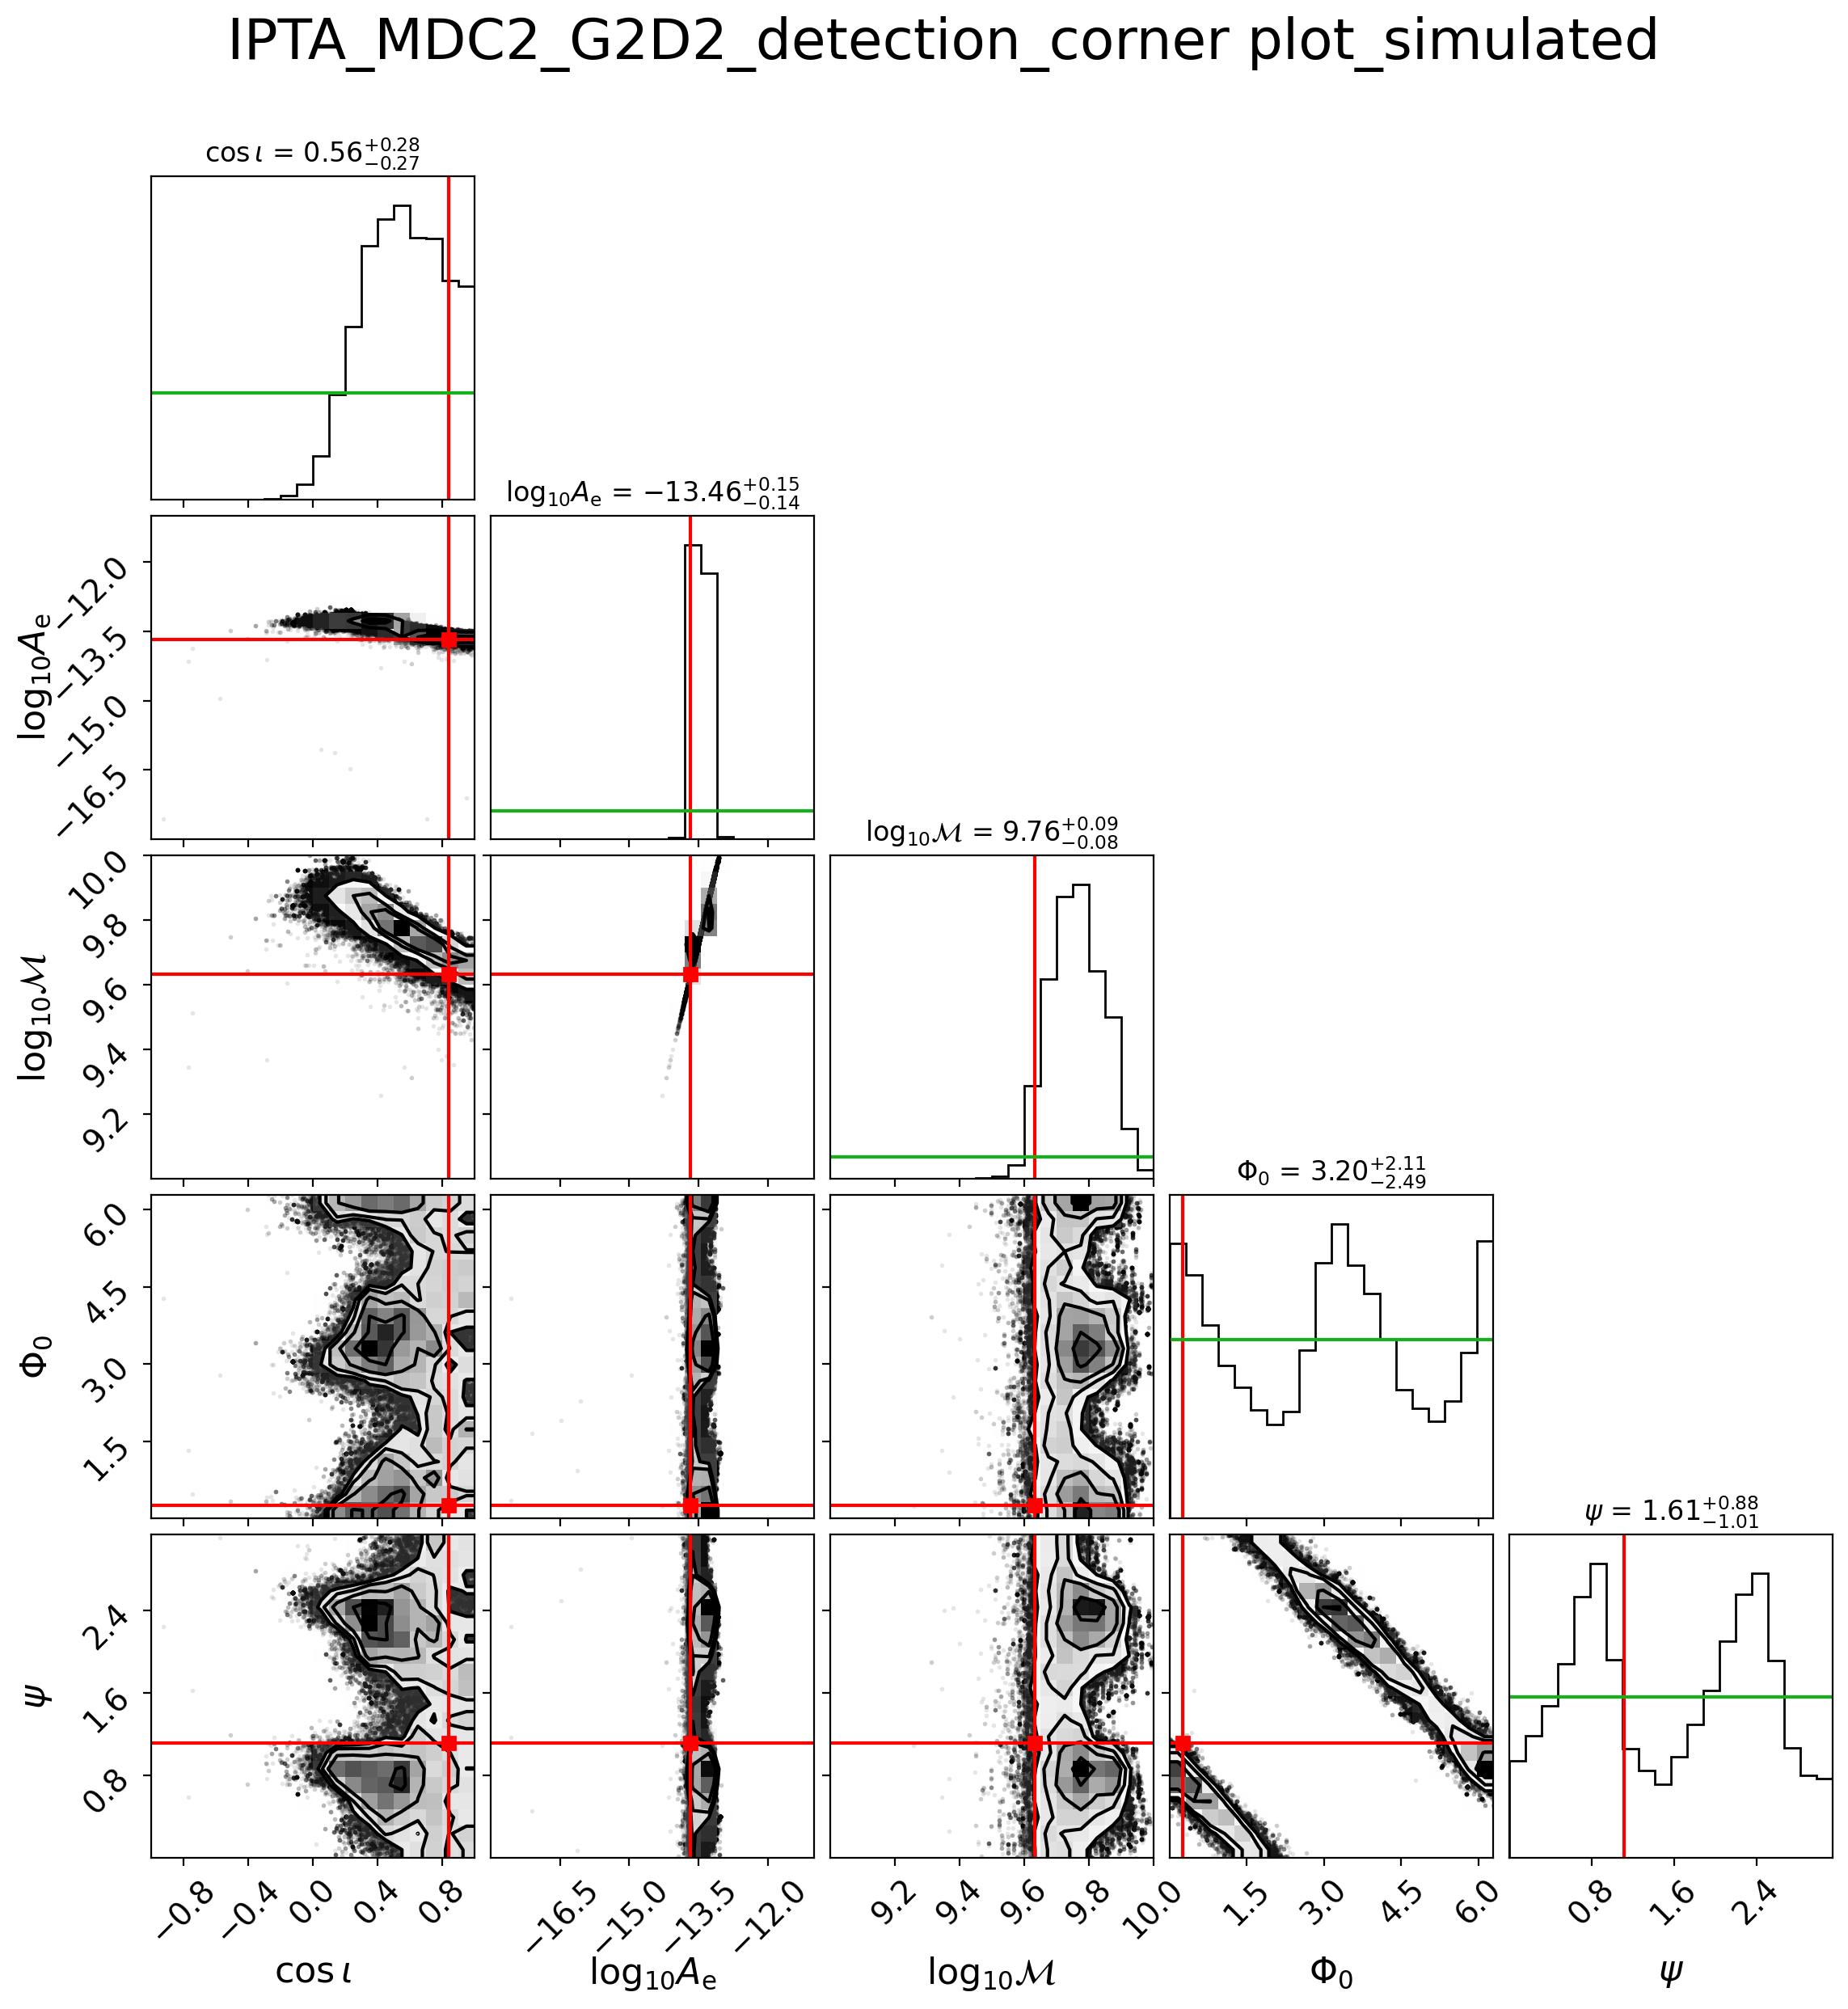

In [7]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)



samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"   # optional, highlights them in red
)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    #elif i==3*(len(labels)+1): #log10_fgw
     #   Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
      #  ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==3*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==4*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

Plotting truth branch ψ=2.690, Φ₀=3.386


Text(0.5, 1.05, 'IPTA_MDC2_G2D2_detection_corner plot_simulated')

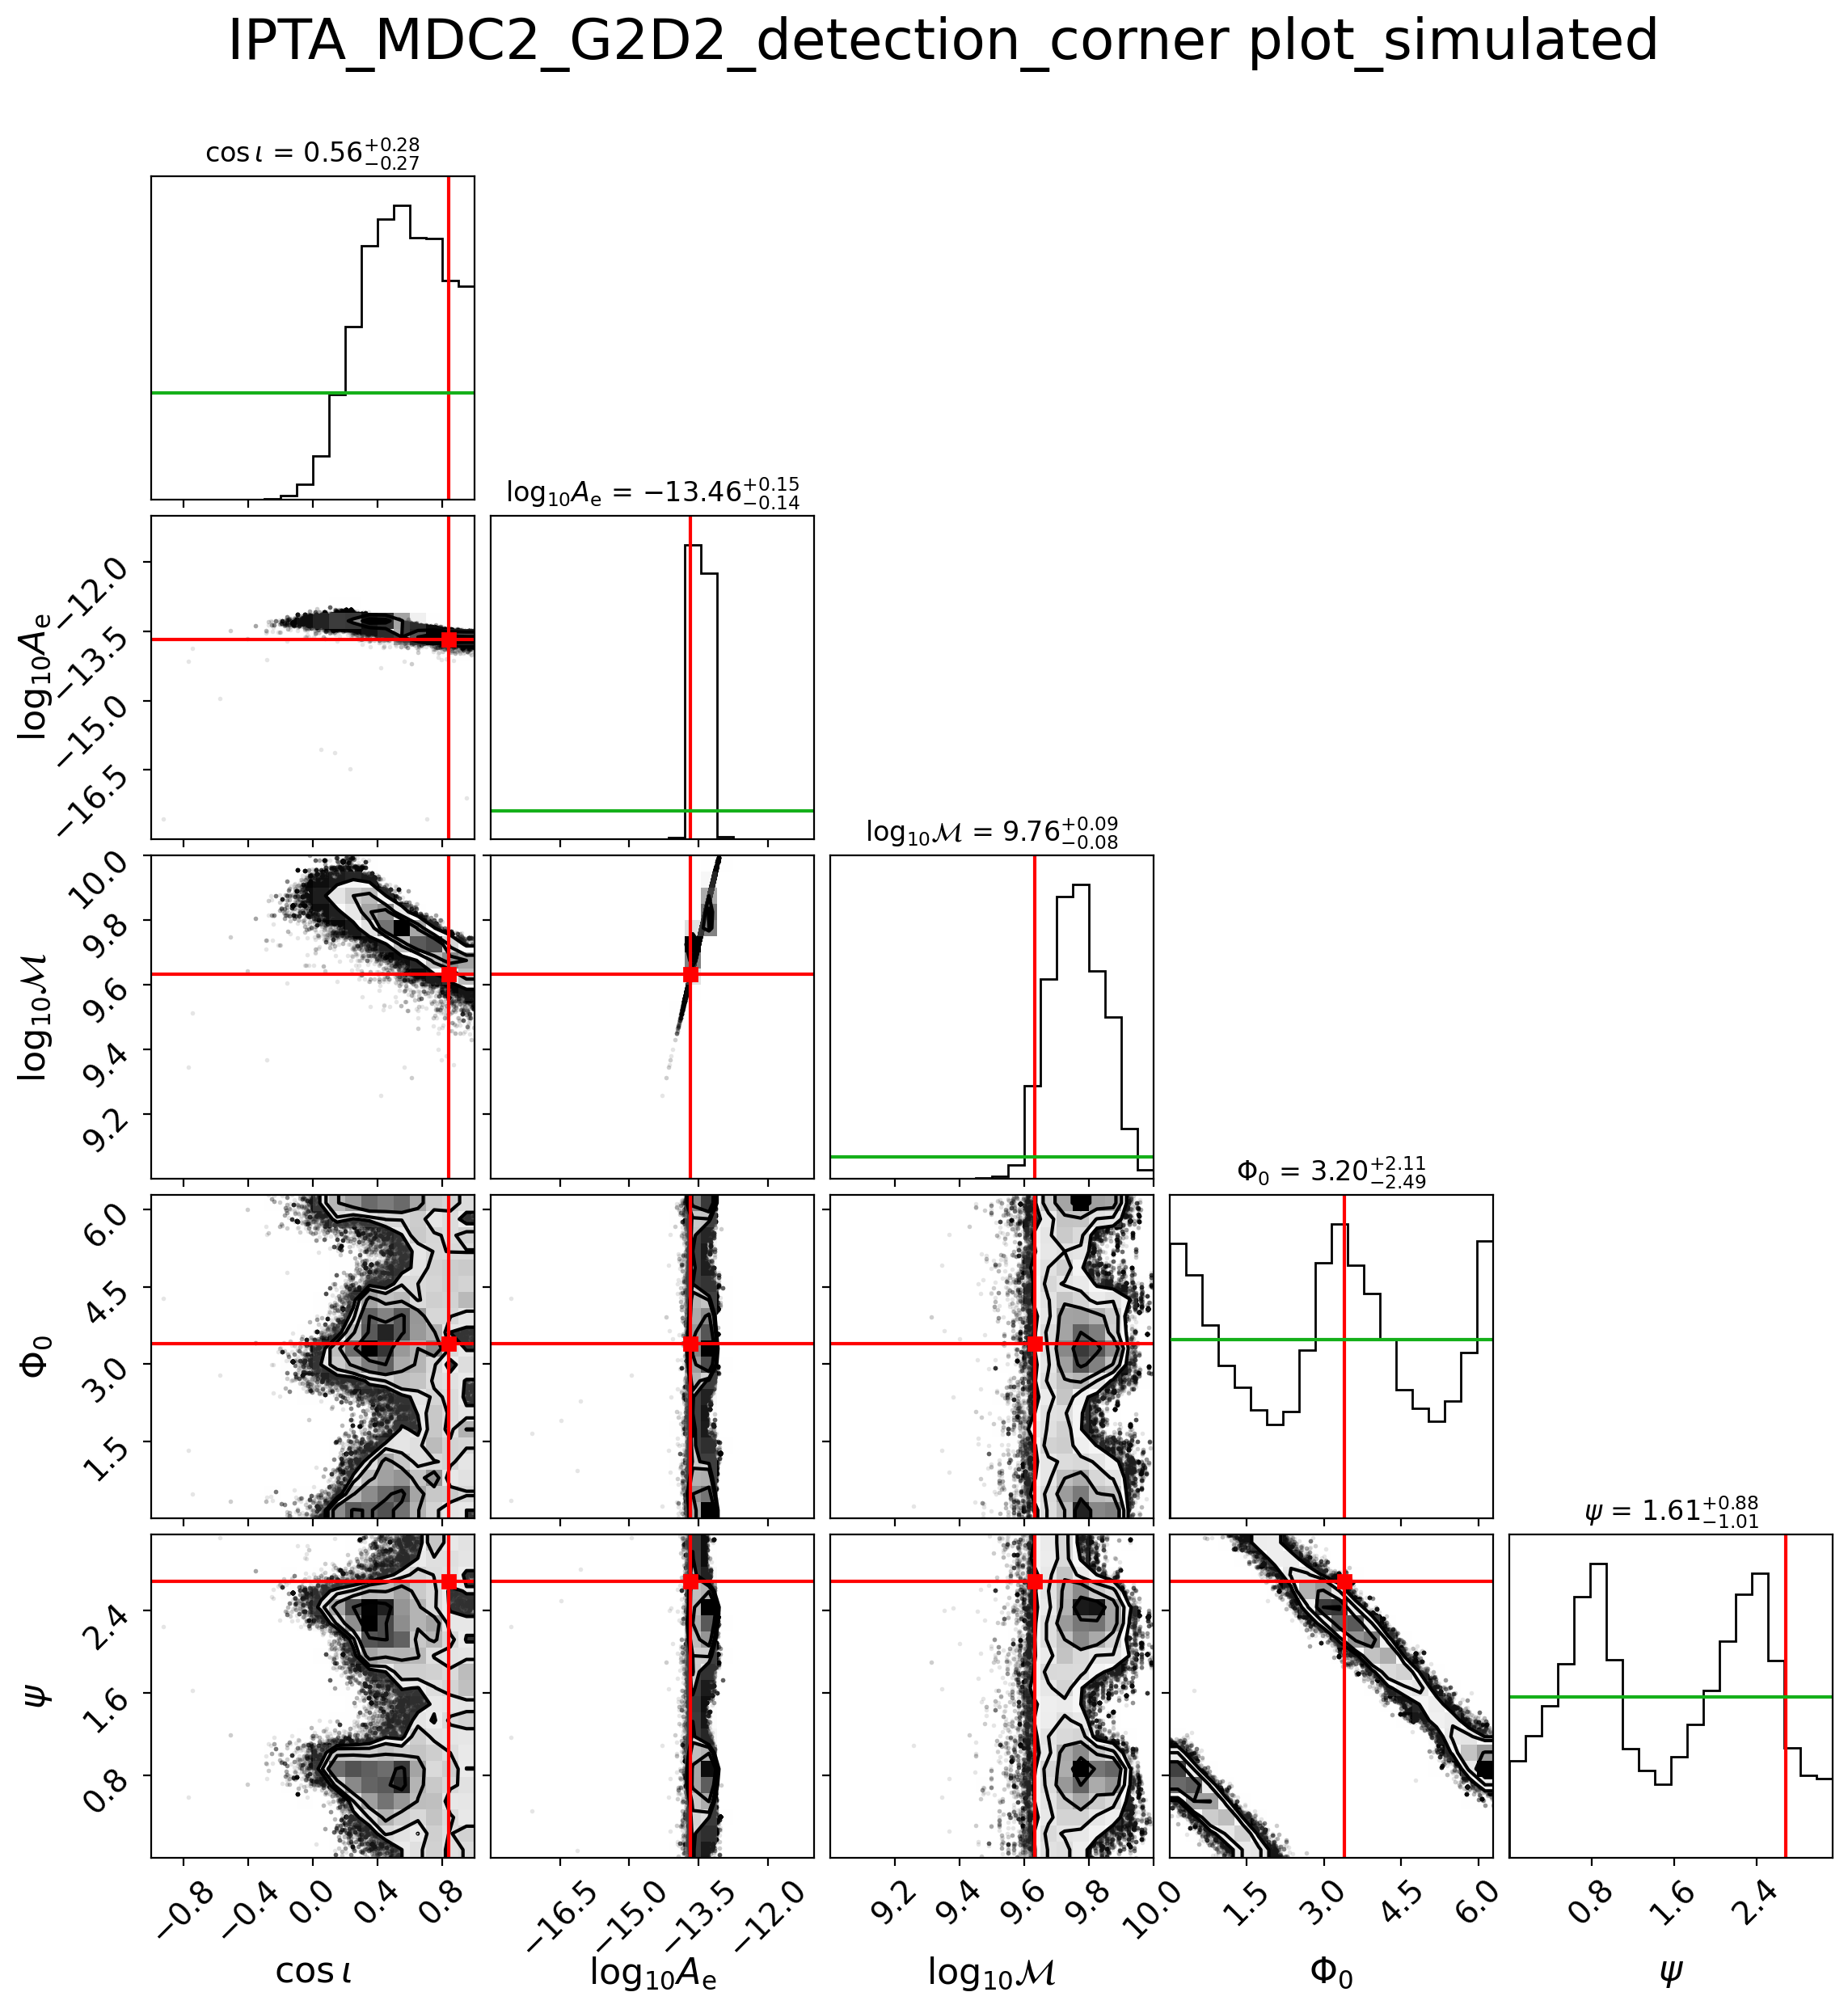

In [8]:
import numpy as np
import corner

# --- your existing code up to truths construction ---
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi", "log10_d_L"]

labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$",
          r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# --- your injected values (from libstempo) ---
psi_inj  = 1.1187560505283651
phi0_inj = 0.24434609527920614

# --- compute median ψ, Φ₀ from samples (after dL mask) ---
psi_samples  = samples2plot[d_L_mask, 7] % np.pi       # ψ ∈ [0, π)
phi0_samples = samples2plot[d_L_mask, 6] % (2*np.pi)   # Φ₀ ∈ [0, 2π)
psi_med  = np.median(psi_samples)
phi0_med = np.median(phi0_samples)

# --- helper for circular diff ---
def angdiff(a, b, period):
    d = (a - b + period/2) % period - period/2
    return abs(d)

# --- all equivalent branches of (ψ, Φ₀) ---
cands = [
    (psi_inj % np.pi,               phi0_inj % (2*np.pi)),           # original
    ((psi_inj + np.pi/2) % np.pi,   (phi0_inj + np.pi) % (2*np.pi)), # +π/2,+π
    ((psi_inj - np.pi/2) % np.pi,   (phi0_inj - np.pi) % (2*np.pi)), # -π/2,-π
]

# --- pick candidate closest to posterior median ---
psi_truth, phi0_truth = min(
    cands,
    key=lambda x: angdiff(x[0], psi_med, np.pi) + angdiff(x[1], phi0_med, 2*np.pi)
)
print(f"Plotting truth branch ψ={psi_truth:.3f}, Φ₀={phi0_truth:.3f}")

# --- truths array for corner() ---
xxx["phase0"] = phi0_truth
xxx["psi"]    = psi_truth
truths = [xxx[label_to_key[l]] for l in labels]

# --- set ranges ---
ranges = [(-1,1), (-18,-11), (9,10), (0,2*np.pi), (0,np.pi)]

# --- corner plot using dL mask samples ---
samples2plot_detect = np.vstack((
    samples2plot[d_L_mask, 1],  # cos i
    samples2plot[d_L_mask, 4],  # log10 A_e
    samples2plot[d_L_mask, 5],  # log10 M_c
    samples2plot[d_L_mask, 6],  # Φ₀
    samples2plot[d_L_mask, 7],  # ψ
)).T

fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)

# --- plot priors (your existing code unchanged) ---
for i, ax in enumerate(fig.axes):
    if i==0:
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==(len(labels)+1):
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==2*(len(labels)+1):
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==3*(len(labels)+1):
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==4*(len(labels)+1):
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

fig.suptitle(crnr_plt_title1, fontsize=25, y=1.05)


/usr/local/anaconda/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3378: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


Ridge slope = -0.6888  (expected ≈ 1.6667 = 5/3)
Intercept   = -6.7257
log10 M (sampled):   median=9.76078  -0.08334/+0.09233
log10 M (implied):   median=9.76061  -0.08290/+0.09249
Δ(log10 M) median (sampled - implied) = 8.58307e-06
Amplitude identity check: median relative error = -3.374e-05,  95% in [-9.45e-03, 9.57e-03]
Relaxed mask 5.0% keeps 933655 samples.


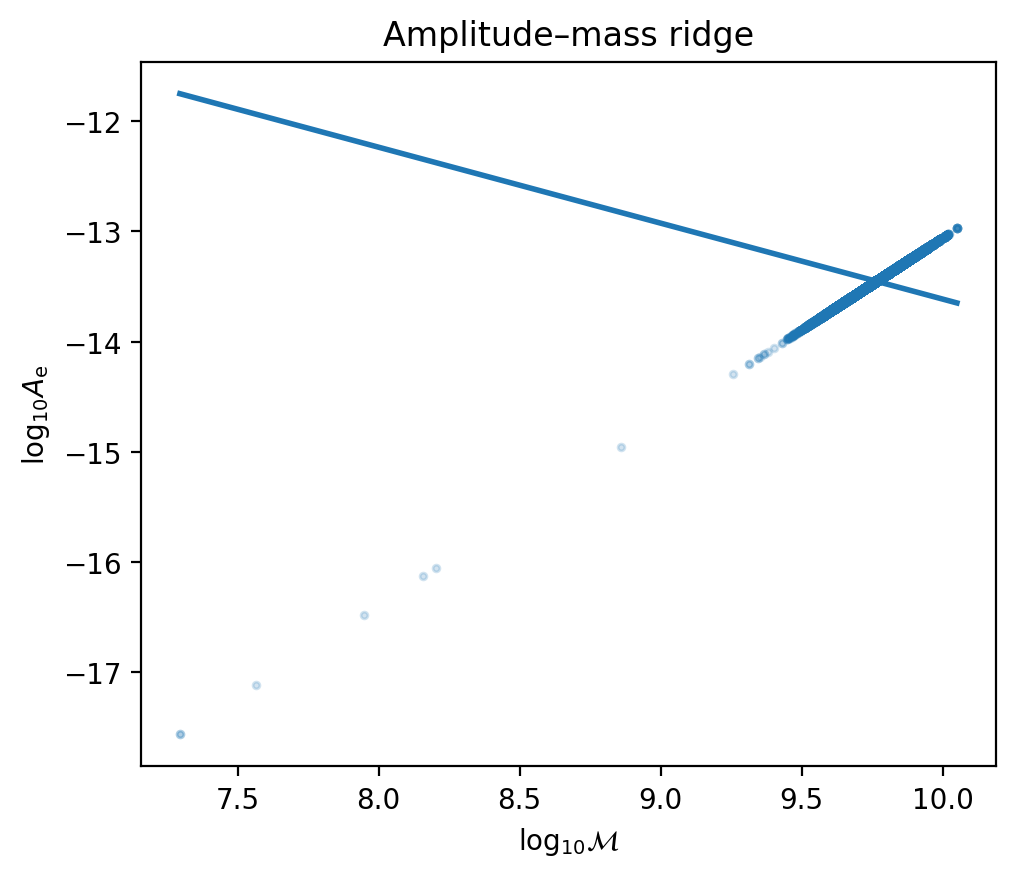

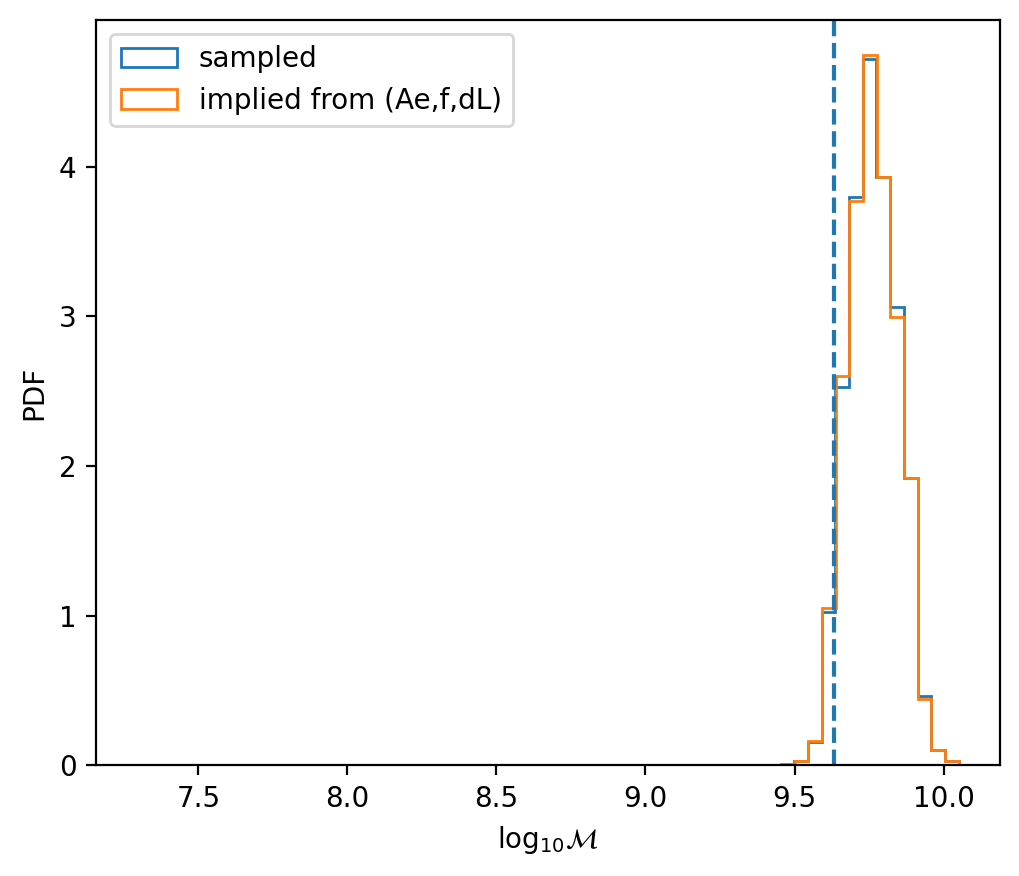

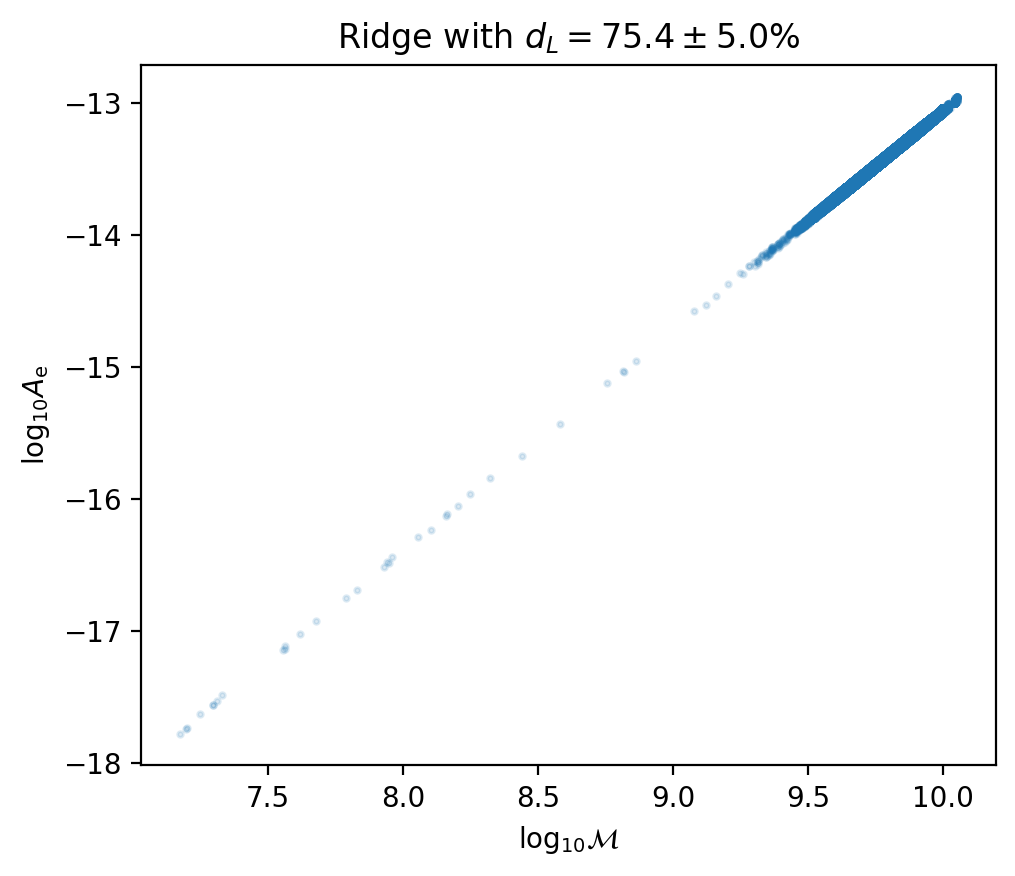

In [9]:
# ====== assumes you already loaded samples_cold, burnin, thin, d_L_mask, target_d_L, T_sun, megaparsec, speed_of_light ======

import numpy as np
import matplotlib.pyplot as plt

# pull arrays
S   = samples_cold[0][burnin::thin]
Ae  = 10.0**S[:,4]
f   = 10.0**S[:,3]
Mc  = 10.0**S[:,5]

# ---------------- 1) Ridge slope: log10(Ae) vs log10(Mc) ----------------
midx = d_L_mask
x = np.log10(Mc[midx])
y = np.log10(Ae[midx])

# robust polyfit (unweighted). If you want Theil–Sen, import from scipy.stats.
slope, intercept = np.polyfit(x, y, 1)
print(f"Ridge slope = {slope:.4f}  (expected ≈ 1.6667 = 5/3)")
print(f"Intercept   = {intercept:.4f}")

plt.figure(figsize=(5.2,4.5))
plt.scatter(x, y, s=6, alpha=0.20)
xg = np.linspace(x.min(), x.max(), 200)
plt.plot(xg, slope*xg + intercept, lw=2)
plt.xlabel(r'$\log_{10}\mathcal{M}$')
plt.ylabel(r'$\log_{10}A_{\rm e}$')
plt.title('Amplitude–mass ridge')
plt.tight_layout()

# ---------------- 2) Reconstruct M from (Ae,f,dL) ----------------
# M_imp = [ Ae * dL * (Mpc/c) / (2*(pi f)^(2/3)) ]^(3/5) / T_sun
Mpc_over_c = megaparsec / speed_of_light
Mc_imp = ((Ae * target_d_L * Mpc_over_c) / (2.0*(np.pi*f)**(2.0/3.0)))**(3.0/5.0) / T_sun

logMc     = np.log10(Mc[midx])
logMc_imp = np.log10(Mc_imp[midx])

def q16_50_84(a):
    return np.percentile(a, [16,50,84])

q_Mc     = q16_50_84(logMc)
q_Mc_imp = q16_50_84(logMc_imp)
print(f"log10 M (sampled):   median={q_Mc[1]:.5f}  -{q_Mc[1]-q_Mc[0]:.5f}/+{q_Mc[2]-q_Mc[1]:.5f}")
print(f"log10 M (implied):   median={q_Mc_imp[1]:.5f}  -{q_Mc_imp[1]-q_Mc_imp[0]:.5f}/+{q_Mc_imp[2]-q_Mc_imp[1]:.5f}")
print(f"Δ(log10 M) median (sampled - implied) = {np.median(logMc - logMc_imp):.5e}")

plt.figure(figsize=(5.2,4.5))
plt.hist(logMc, bins=60, histtype='step', density=True, label='sampled')
plt.hist(logMc_imp, bins=60, histtype='step', density=True, label='implied from (Ae,f,dL)')
plt.axvline(np.log10(4.3e9), ls='--')  # injected truth
plt.xlabel(r'$\log_{10}\mathcal{M}$')
plt.ylabel('PDF')
plt.legend()
plt.tight_layout()

# Optional: verify amplitude identity directly
Ae_pred = 2.0*(Mc*T_sun)**(5.0/3.0) * (np.pi*f)**(2.0/3.0) / (target_d_L * Mpc_over_c)
rel = (Ae - Ae_pred)/Ae_pred
print(f"Amplitude identity check: median relative error = {np.median(rel[midx]):.3e},  95% in [{np.percentile(rel[midx],2.5):.2e}, {np.percentile(rel[midx],97.5):.2e}]")

# ---------------- 3) Relax the dL mask to visualize the ridge ----------------
tol_pct = 5.0  # try 5–10%
dL = 2.0*(Mc*T_sun)**(5.0/3.0) * (np.pi*f)**(2.0/3.0) / Ae * (speed_of_light/megaparsec)
lo = target_d_L*(1 - tol_pct/100.0)
hi = target_d_L*(1 + tol_pct/100.0)
mask_relaxed = np.where((dL>=lo) & (dL<=hi))[0]
print(f"Relaxed mask {tol_pct:.1f}% keeps {mask_relaxed.size} samples.")

plt.figure(figsize=(5.2,4.5))
plt.scatter(np.log10(Mc[mask_relaxed]), np.log10(Ae[mask_relaxed]), s=4, alpha=0.15)
plt.xlabel(r'$\log_{10}\mathcal{M}$'); plt.ylabel(r'$\log_{10}A_{\rm e}$')
plt.title(fr'Ridge with $d_L={target_d_L}\pm{tol_pct}\%$')
plt.tight_layout()


In [10]:
# sampled Mc posterior (after masking)
log10Mc_samples = samples2plot[d_L_mask, 5]   # or whatever column index for log10 M is

# injected truth
truth_log10Mc = np.log10(4.3e9)  # from your injection
q = np.quantile(log10Mc_samples, [0.05,0.16,0.5,0.84,0.95])
delta = (truth_log10Mc - np.mean(log10Mc_samples)) / np.std(log10Mc_samples, ddof=1)
print("q05..q95:", q, " z≈", delta)


q05..q95: [9.63228893 9.67743397 9.76077557 9.85310555 9.89662743]  z≈ -1.5757728162603704


In [11]:
# sampled psi posterior (after masking)
log10psi_samples = samples2plot[d_L_mask, 7]   # or whatever column index for log10 M is

# injected truth
truth_log10psi = 1.1187560505283651  # from your injection
q = np.quantile(log10psi_samples, [0.05,0.16,0.5,0.84,0.95])
delta = (truth_log10psi - np.mean(log10psi_samples)) / np.std(log10psi_samples, ddof=1)
print("q05..q95:", q, " z≈", delta)


q05..q95: [0.24112514 0.59253627 1.60628748 2.48158503 2.82826161]  z≈ -0.496469264425312


In [12]:
# exact masked arrays
x = np.asarray(samples2plot[d_L_mask, 5], float)   # log10 Mc
y = np.asarray(samples2plot[d_L_mask, 4], float)   # log10 Ae

# drop any NaNs, infs
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

# optional: unique pairs to avoid duplicates that wreck conditioning
pairs = np.unique(np.round(np.c_[x, y], 6), axis=0)
xu, yu = pairs[:,0], pairs[:,1]

# quick robust slope checks that must all be ~ +1.6667
def slope_cov(x,y):
    dx = x - x.mean()
    dy = y - y.mean()
    return (dx@dy)/(dx@dx)

print("slope(cov/var) =", slope_cov(xu,yu))

# percentile two-point slope
xl, xh = np.percentile(xu, [10, 90])
yl = yu[np.argmin(np.abs(xu - xl))]
yh = yu[np.argmin(np.abs(xu - xh))]
print("slope(p10→p90) =", (yh - yl) / (xh - xl))

# plain polyfit on de-duplicated data
coef = np.polyfit(xu, yu, 1)     # [slope, intercept]
print("slope(polyfit) =", coef[0], "intercept =", coef[1])


slope(cov/var) = 1.666300804327788
slope(p10→p90) = 1.665995985248117
slope(polyfit) = 1.666300804327901 intercept = -29.721011176741268


hamp [1.9754877e-14 1.8223770e-14 3.9222945e-15 ... 3.0472271e-14 3.0472271e-14
 3.0472271e-14]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [1.3260140e+10 1.3260140e+10 1.8165877e+08 ... 1.6658205e+10 1.6658205e+10
 1.6658205e+10]
Length of logdL 100000000
required values 8.379901 3.7000025e-09 13260140000.0 3.2532872e-14
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [534.57745   579.4911      2.1118288 ... 506.88986   506.88986
 506.88986  ]
min 10**log10_d_L 0.0007726819
max 10**log10_d_L 239828580.0
d_L_mask [    7076     7081     7250 ... 99970462 99970463 99970464]
notd_L_mask1 [       2      541      554 ... 99999579 99999934 99999957]
notd_L_mask2 [       0        1        3 ... 99999997 99999998 99999999]
merged_non_dL [       2      541      554 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 186472
9


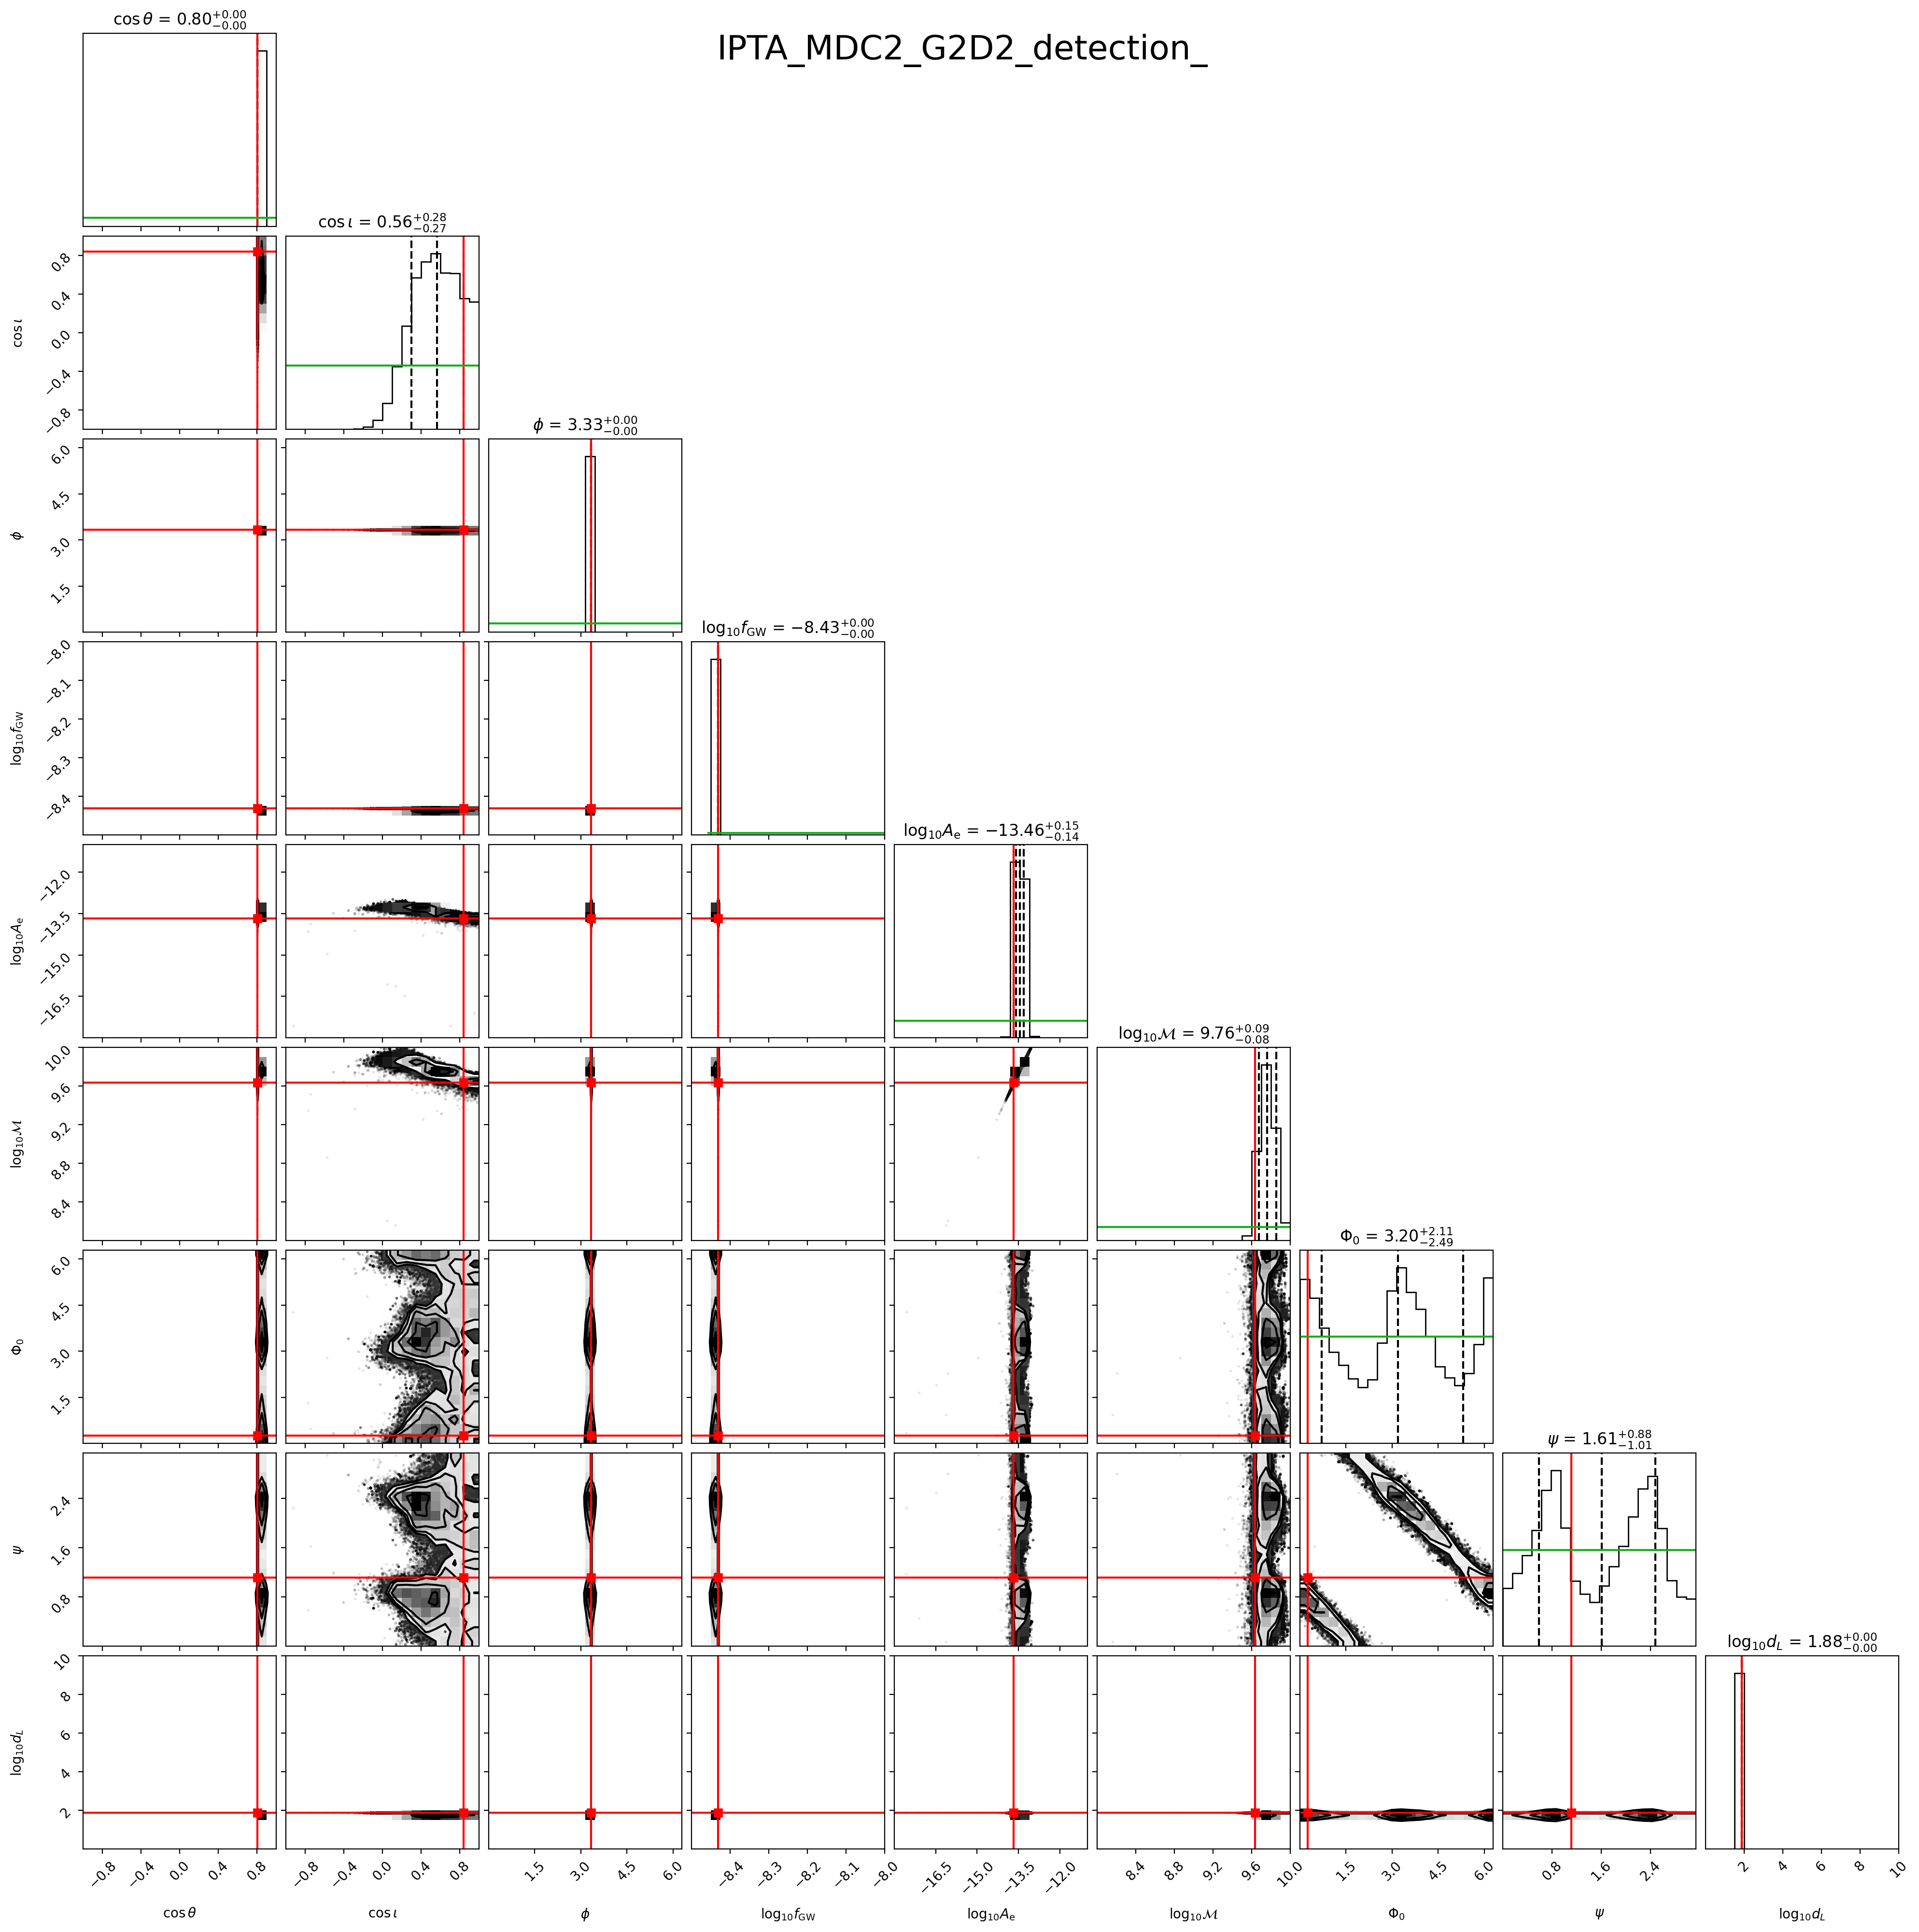

In [13]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
          r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
          
# Mapping from pretty labels → xxx0 keys
label_to_key = {
    r"$\cos \theta$": "0_cos_gwtheta",
    r"$\cos \iota$": "0_cos_inc",
    r"$\phi$": "0_gwphi",
    r"$\log_{10} f_{\rm GW}$": "0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
    r"$\log_{10} d_L$": "distance"
}

# Build truths list (log-transform distance for d_L)
truths = []
for lab in labels:
    key = label_to_key[lab]
    if lab == r"$\log_{10} d_L$":
        truths.append(np.log10(xxx0[key]))
    else:
        truths.append(xxx0[key])
        
#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.5,-8), (-18,-11), (8,10), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
target_d_L = 75.4#Mpc
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

#fig = corner.corner(samples2plot[d_L_mask, :],
 #                   labels=labels,
  #                  show_titles=True, quantiles=[0.16, 0.5, 0.84],
   #                 range=ranges, hist_kwargs={"density":True})

fig = corner.corner(
    samples2plot[d_L_mask, :],   # <-- use samples2plot, not samples2plot_detect
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0 or i==(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==2*(len(labels)+1) or i==6*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_fgw
        Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==4*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==5*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(7.84, 10.26)
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==7*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
fig.suptitle(crnr_plt_title2, fontsize = 25);

## Trace Plots

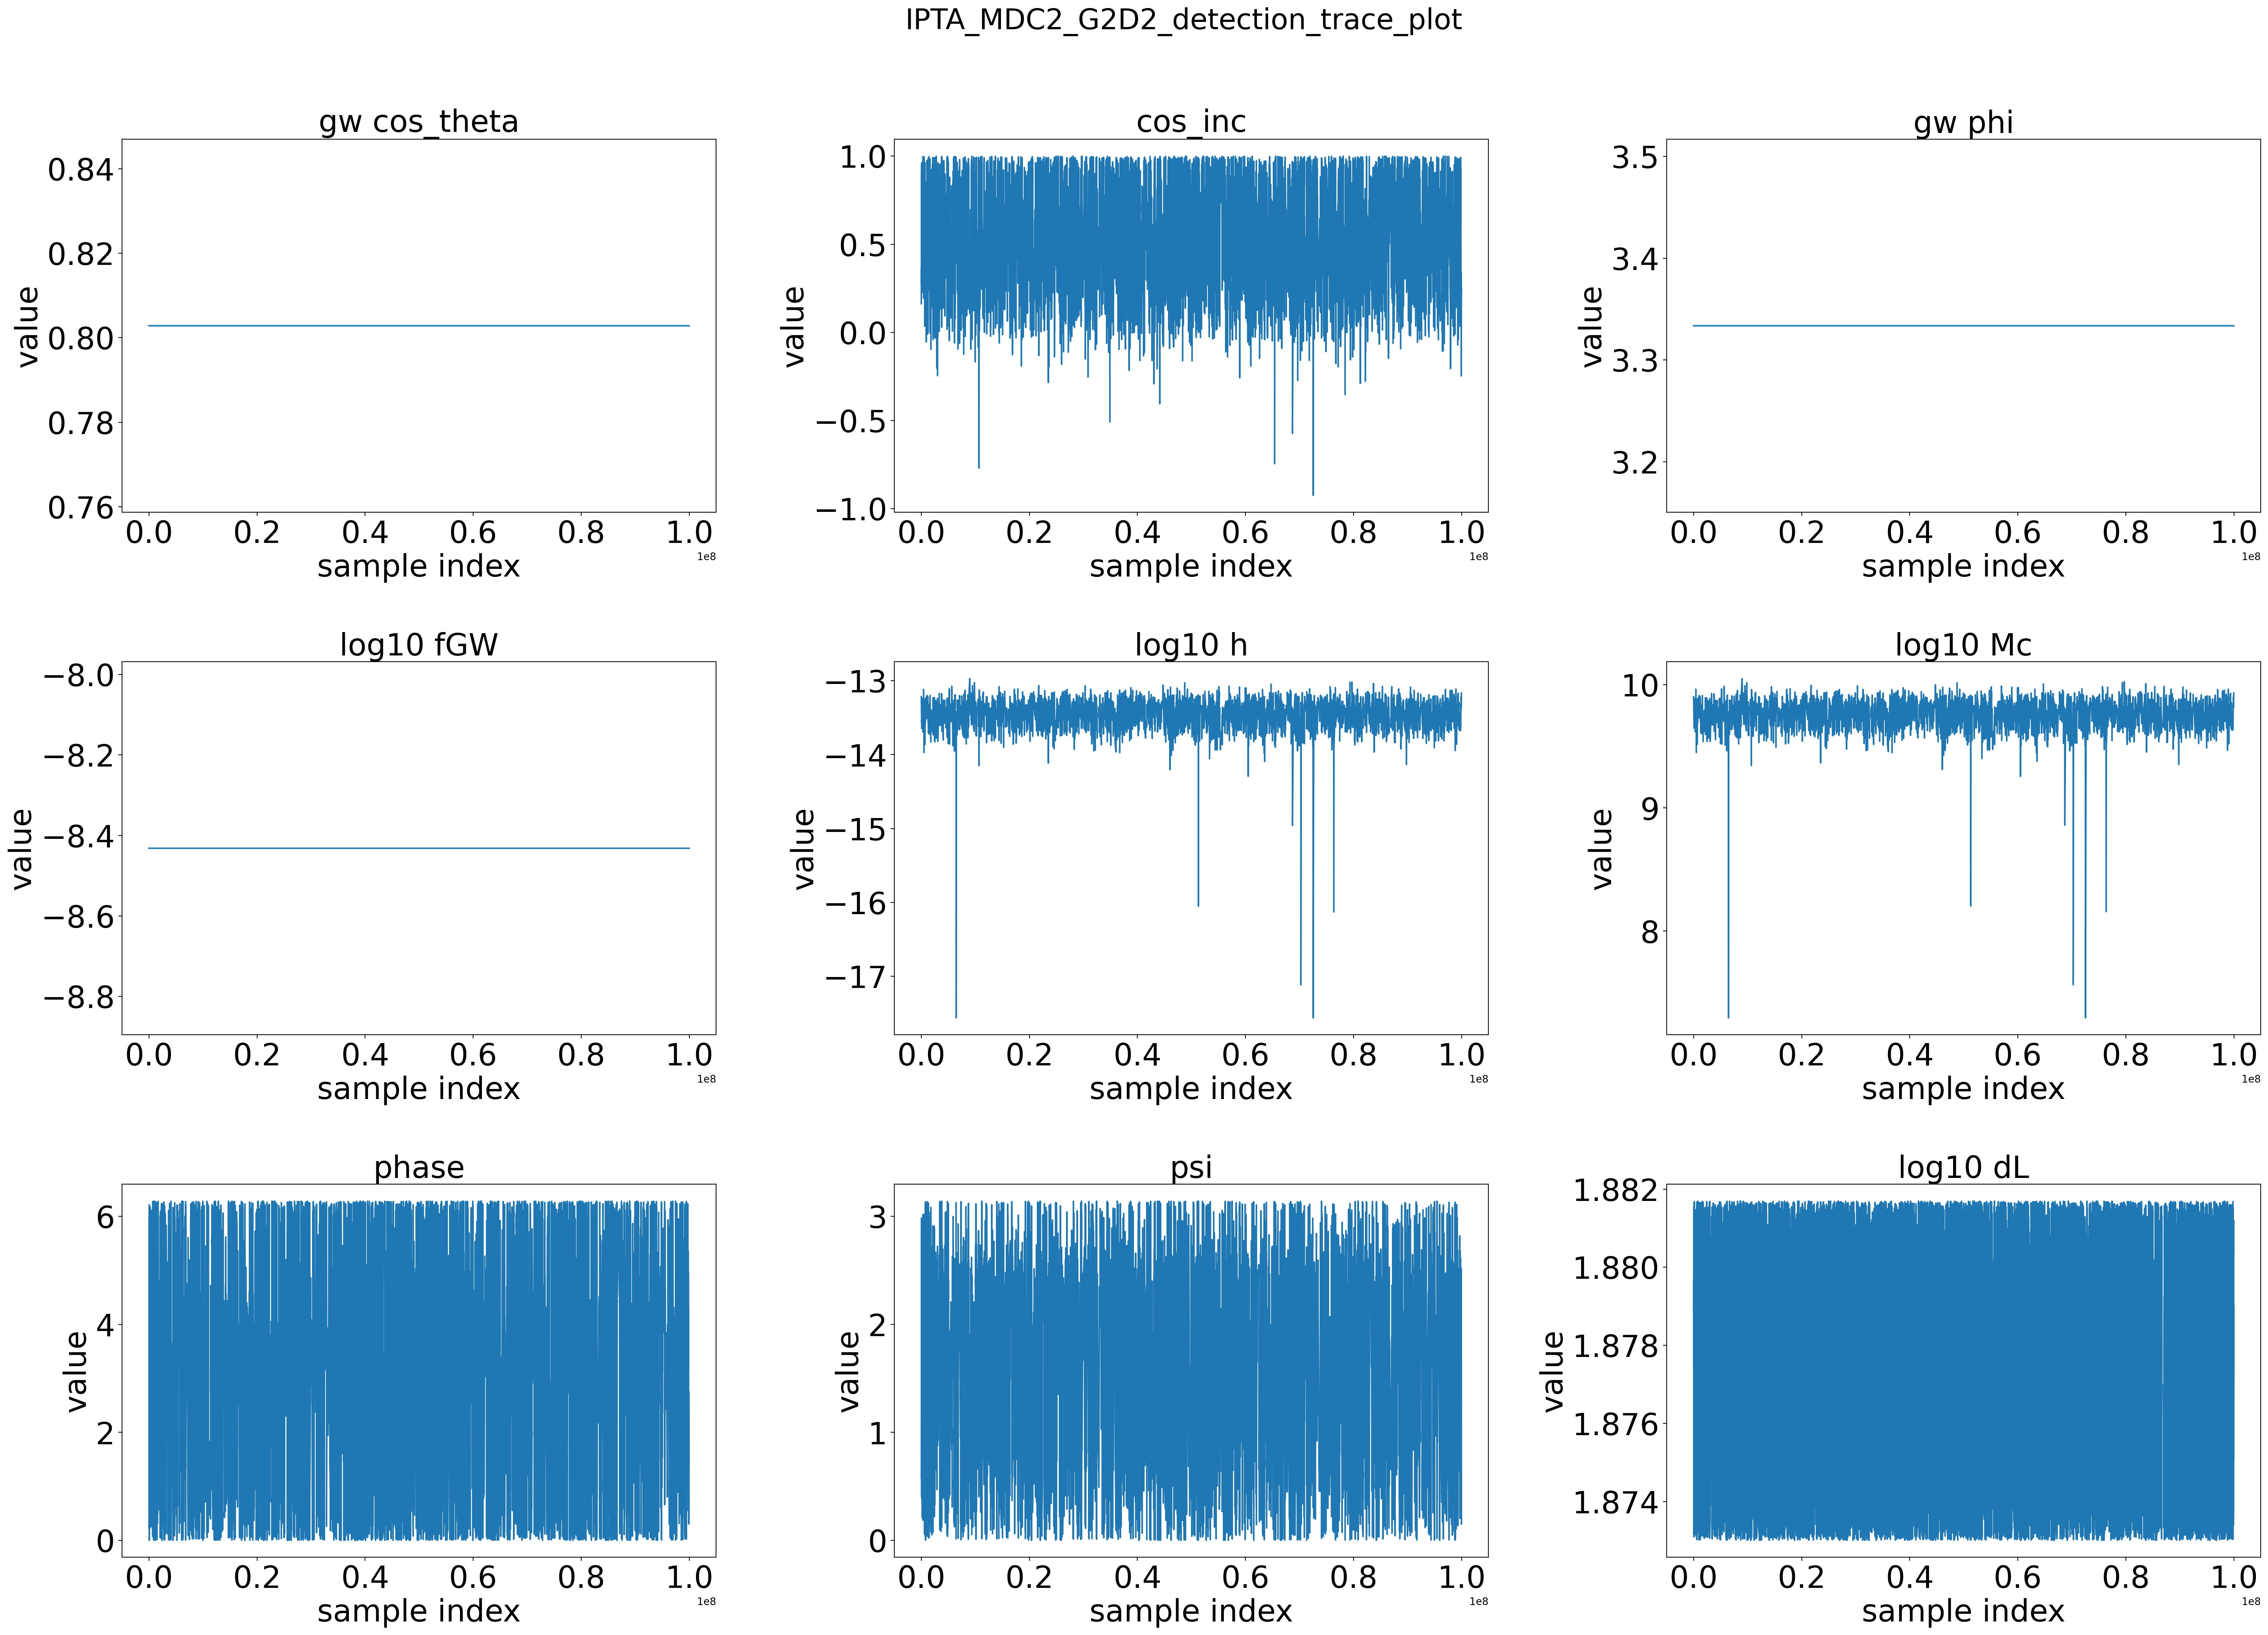

In [14]:
import matplotlib.pyplot as plt

title = ["gw cos_theta", "cos_inc", "gw phi", "log10 fGW", 
         "log10 h", "log10 Mc", "phase", "psi", "log10 dL"]

j = -1
row, column = 3, 3
fig, axs = plt.subplots(row, column, figsize=(30, 20))
fig.tight_layout(h_pad=3, w_pad=2)

# Loop over parameters
for i in range(len(title)): 
    if i % column == 0:
        j += 1
    axs[j, i % column].plot(d_L_mask, samples2plot[d_L_mask, i])
    axs[j, i % column].set_title(title[i], fontsize=30)    # bigger subplot title
    axs[j, i % column].tick_params(axis="both", labelsize=30)  # bigger tick labels
    axs[j, i % column].set_xlabel("sample index", fontsize=30)
    axs[j, i % column].set_ylabel("value", fontsize=30)

# Global title
fig.suptitle(trace_plot_title, fontsize=28, y=1.08)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  # more spacing
#plt.show()
#plt.savefig("trace_plots.png", dpi=200, bbox_inches="tight")


In [15]:
print(np.min(samples2plot[d_L_mask,5]))
print(np.max(np.log10(samples2plot[d_L_mask,5])))

7.295124e+00
1.0021865


## SD BF

hmin -17.562662
hmax -12.97277
Mc min 7.295124
Mc max 10.050475
186472


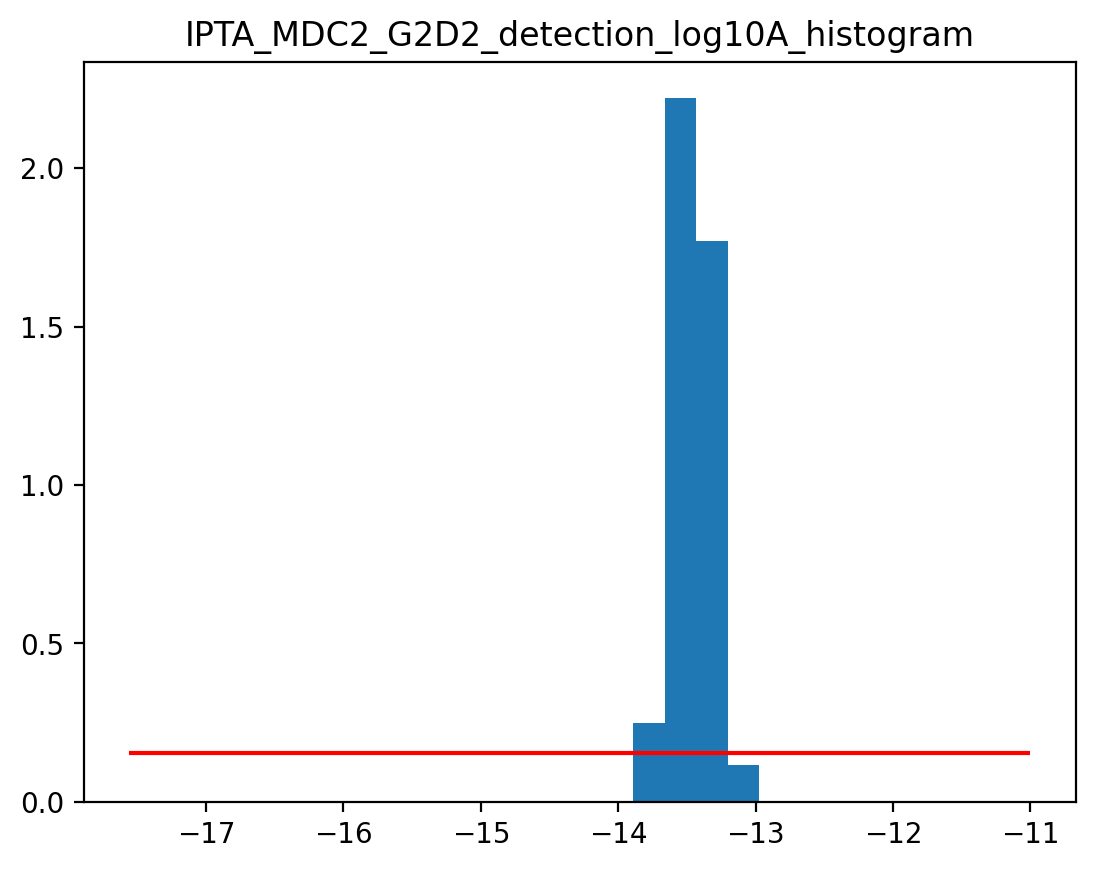

In [16]:
logAmin_dL = np.min(samples2plot[d_L_mask,4])
logAmax_dL = np.max(samples2plot[d_L_mask,4])
print("hmin",logAmin_dL)
print("hmax",logAmax_dL)
print("Mc min",np.min(samples2plot[d_L_mask,5]))
print("Mc max",np.max(samples2plot[d_L_mask,5]))

print(len(samples2plot[d_L_mask,4]))

plt.hist(samples2plot[d_L_mask,4], bins=20, density=True)
plt.hlines(1/(-11 - logAmin_dL), logAmin_dL, -11,  color='red')
plt.title(BF_histogram_title)
plt.show()

/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


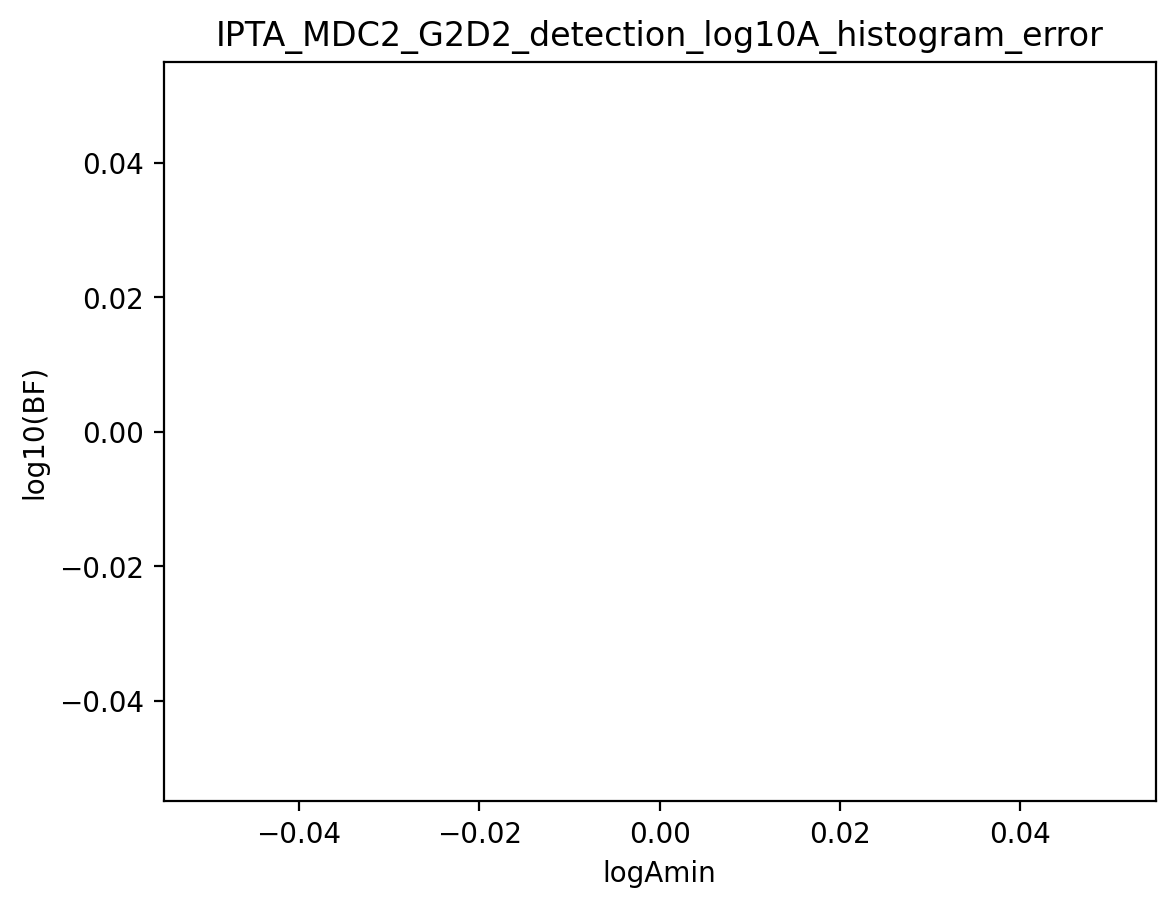

In [17]:
#d_L correlated SD BF
logamins = np.linspace(logAmin_dL, -15, 100)
BF_arr = []
BF_err_arr = []

from enterprise_extensions import model_utils
for logamin in logamins:
    BF,BF_err = model_utils.bayes_fac(samples = samples2plot[d_L_mask,4], logAmin=logamin, logAmax=-11)
    BF_arr.append(BF)
    BF_err_arr.append(BF_err)

plt.errorbar(logamins, BF_arr, yerr=BF_err_arr, fmt='o')
plt.xlabel('logAmin')
plt.ylabel("log10(BF)")
plt.title(BFerr_title)
plt.show()

In [18]:
#d_L correlated SD BF
BF, BF_err = model_utils.bayes_fac(samples=samples2plot[d_L_mask,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = nan ± nan


/usr/local/anaconda/lib/python3.9/site-packages/enterprise_extensions/model_utils.py:194: RuntimeWarning: divide by zero encountered in double_scalars
  bf.append(prior/post)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/usr/local/anaconda/lib/python3.9/site-packages/numpy/core/_methods.py:254: RuntimeWarning: i

In [19]:
#Non d_L correlated SD BF
from enterprise_extensions import model_utils
BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::10,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = nan ± nan


In [20]:
print(BF_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [21]:
print(BF_err_arr[0:10])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
